# Heavy-end characterization: Whitson and Pedersen literature validation

This notebook tests the model-neutral `torch_flash.characterization` package
against two fully worked literature cases:

1. Whitson and Brulé, *Phase Behavior*, SPE Monograph 20 (2000), Chapter 5,
   Table 5.4: 20-bin shifted-gamma splits at
   \(\alpha=0.5,1,2\), \(\eta=90\) g/mol, and
   \(\overline M_{C7+}=200\) g/mol.
2. Pedersen, Christensen, and Shaikh, *Phase Behavior of Petroleum Reservoir
   Fluids*, 3rd ed. (2024), Chapter 5, Tables 5.4, 5.8, and 5.9:
   characterization of a North Sea condensate C20+ fraction, SRK property
   estimation, and equal-weight lumping into three C7+ pseudo-components.

The calculations are intentionally separate from CPA, PR, or any other phase
model until the property-adapter step. This makes splitting and lumping
reusable. All model inputs below retain SI units in the API; tables are
converted only for presentation.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from torch_flash import (
    SCNDistribution,
    equal_weight_lump,
    pedersen_cubic_properties,
    pedersen_density_split,
    pedersen_logarithmic_split,
    whitson_gamma_split,
)

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")

## Whitson Table 5.4: cut-by-cut gamma-distribution reproduction

GAMSPL places molecular-weight boundaries at
\(\eta,\eta+14,\eta+28,\ldots\) g/mol and puts the remaining infinite tail
in the final bin. The latter differs from treating carbon-number masses as
bin midpoints. The published rounded values below are transcribed directly
from Table 5.4.

In [2]:
whitson_reference = {
    0.5: {
        "z": [
            0.2787233,
            0.1073842,
            0.0772607,
            0.0610991,
            0.0505020,
            0.0428377,
            0.0369618,
            0.0322804,
            0.0284480,
            0.0252470,
            0.0225321,
            0.0202013,
            0.0181808,
            0.0164152,
            0.0148619,
            0.0134879,
            0.0122665,
            0.0111762,
            0.0101996,
            0.1199341,
        ],
        "M": [
            94.588,
            110.525,
            124.690,
            138.758,
            152.796,
            166.819,
            180.836,
            194.848,
            208.857,
            222.864,
            236.870,
            250.875,
            264.879,
            278.883,
            292.886,
            306.888,
            320.890,
            334.892,
            348.894,
            539.651,
        ],
    },
    1.0: {
        "z": [
            0.1195065,
            0.1052247,
            0.0926497,
            0.0815774,
            0.0718284,
            0.0632444,
            0.0556863,
            0.0490314,
            0.0431719,
            0.0380125,
            0.0334698,
            0.0294699,
            0.0259481,
            0.0228471,
            0.0201167,
            0.0177127,
            0.0155959,
            0.0137321,
            0.0120910,
            0.0890834,
        ],
        "M": [
            96.852,
            110.852,
            124.852,
            138.852,
            152.852,
            166.852,
            180.852,
            194.852,
            208.852,
            222.852,
            236.852,
            250.852,
            264.852,
            278.852,
            292.852,
            306.852,
            320.852,
            334.852,
            348.852,
            466.000,
        ],
    },
    2.0: {
        "z": [
            0.0273900,
            0.0655834,
            0.0852269,
            0.0927292,
            0.0925552,
            0.0877762,
            0.0804707,
            0.0720157,
            0.0632969,
            0.0548597,
            0.0470180,
            0.0399302,
            0.0336535,
            0.0281813,
            0.0234690,
            0.0194514,
            0.0160543,
            0.0132017,
            0.0108204,
            0.0463166,
        ],
        "M": [
            99.132,
            111.490,
            125.172,
            139.038,
            152.963,
            166.916,
            180.883,
            194.859,
            208.841,
            222.826,
            236.814,
            250.805,
            264.797,
            278.790,
            292.784,
            306.778,
            320.774,
            334.770,
            348.766,
            420.424,
        ],
    },
}

whitson_rows = []
whitson_results = {}
for shape, reference in whitson_reference.items():
    calculated = whitson_gamma_split(
        1.0,
        0.200,
        first_carbon_number=7,
        max_carbon_number=26,
        shape=shape,
        minimum_molar_mass=0.090,
    )
    whitson_results[shape] = calculated
    for index, (z_ref, mass_ref) in enumerate(
        zip(reference["z"], reference["M"], strict=True)
    ):
        whitson_rows.append(
            {
                "alpha": shape,
                "bin": index + 1,
                "z_table": z_ref,
                "z_torch_flash": float(calculated.mole_fractions[index]),
                "M_table_g_mol": mass_ref,
                "M_torch_flash_g_mol": float(calculated.molar_masses[index] * 1.0e3),
            }
        )
whitson_comparison = pd.DataFrame(whitson_rows)
whitson_comparison["z_absolute_error"] = (
    whitson_comparison["z_torch_flash"] - whitson_comparison["z_table"]
).abs()
whitson_comparison["M_absolute_error_g_mol"] = (
    whitson_comparison["M_torch_flash_g_mol"] - whitson_comparison["M_table_g_mol"]
).abs()
display(
    whitson_comparison.groupby("alpha")[
        ["z_absolute_error", "M_absolute_error_g_mol"]
    ].max()
)
assert whitson_comparison["z_absolute_error"].max() < 6.0e-7
assert whitson_comparison["M_absolute_error_g_mol"].max() < 1.1e-3

,z_absolute_error,M_absolute_error_g_mol
alpha,,
0.5,5.053328e-08,0.000493
1.0,4.468974e-08,0.000445
2.0,4.874599e-08,0.000496


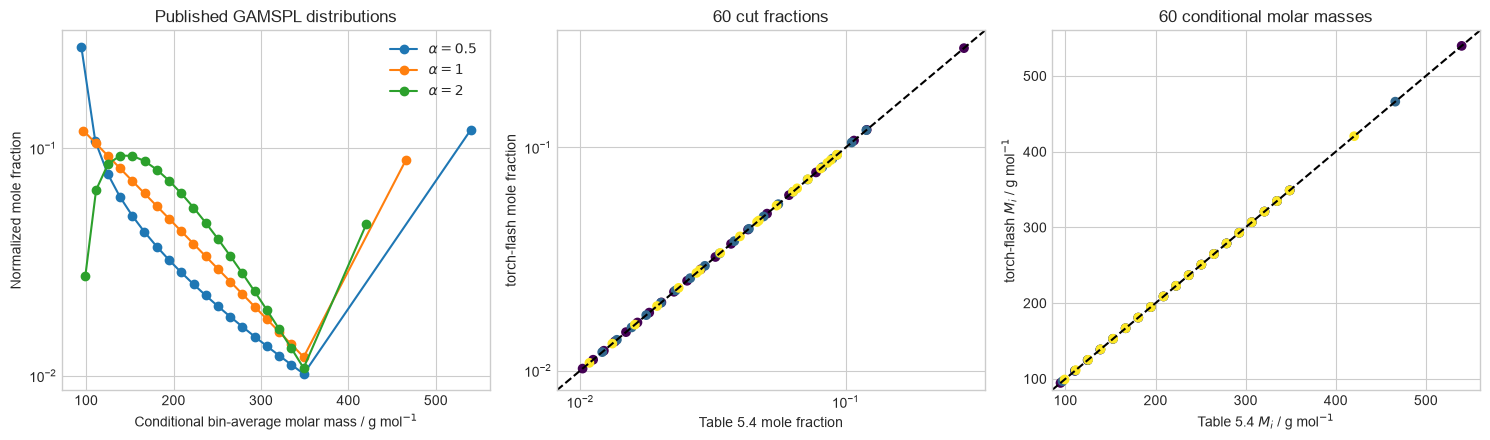

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for shape, result in whitson_results.items():
    axes[0].semilogy(
        result.molar_masses.detach() * 1.0e3,
        result.mole_fractions.detach(),
        "o-",
        label=rf"$\alpha={shape:g}$",
    )
axes[0].set(
    xlabel="Conditional bin-average molar mass / g mol$^{-1}$",
    ylabel="Normalized mole fraction",
    title="Published GAMSPL distributions",
)
axes[0].legend()

axes[1].scatter(
    whitson_comparison["z_table"],
    whitson_comparison["z_torch_flash"],
    c=whitson_comparison["alpha"],
    cmap="viridis",
)
z_limits = [
    whitson_comparison["z_table"].min() * 0.8,
    whitson_comparison["z_table"].max() * 1.2,
]
axes[1].plot(z_limits, z_limits, "k--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set(
    xlim=z_limits,
    ylim=z_limits,
    xlabel="Table 5.4 mole fraction",
    ylabel="torch-flash mole fraction",
    title="60 cut fractions",
)

axes[2].scatter(
    whitson_comparison["M_table_g_mol"],
    whitson_comparison["M_torch_flash_g_mol"],
    c=whitson_comparison["alpha"],
    cmap="viridis",
)
m_limits = [85.0, 560.0]
axes[2].plot(m_limits, m_limits, "k--")
axes[2].set(
    xlim=m_limits,
    ylim=m_limits,
    xlabel=r"Table 5.4 $M_i$ / g mol$^{-1}$",
    ylabel=r"torch-flash $M_i$ / g mol$^{-1}$",
    title="60 conditional molar masses",
)
fig.tight_layout()
plt.show()

The moment balance is checked independently of the table transcription. The
final bin contains the complete tail, so total mole fraction and mean molar
mass are preserved to floating-point precision rather than only to Table
5.4's printed digits.

In [4]:
whitson_balances = pd.DataFrame(
    [
        {
            "alpha": shape,
            "sum_z": float(result.total_mole_fraction),
            "average_M_g_mol": float(result.average_molar_mass * 1.0e3),
            "tail_z": float(result.mole_fractions[-1]),
            "tail_M_g_mol": float(result.molar_masses[-1] * 1.0e3),
        }
        for shape, result in whitson_results.items()
    ]
)
display(whitson_balances)
assert np.allclose(whitson_balances["sum_z"], 1.0, atol=2.0e-15)
assert np.allclose(whitson_balances["average_M_g_mol"], 200.0, atol=2.0e-12)

,alpha,sum_z,average_M_g_mol,tail_z,tail_M_g_mol
0,0.5,1.0,200.0,0.119934,539.651216
1,1.0,1.0,200.0,0.089083,466.000000
2,2.0,1.0,200.0,0.046317,420.423676


## Pedersen Tables 5.4 and 5.8: North Sea condensate

Table 5.4 reports measured C7–C19 cuts and a C20+ fraction with
\(z_+=0.833\%\), \(\overline M_+=377\) g/mol, and
\(\rho_+=0.873\) g/cm³. Equations 5.10–5.12 split the plus fraction through
C80. Equation 5.20 assigns \(\rho_N=C+D\ln(CN)\), constrained here by the
measured C19 density and the C20+ volume balance. SRK properties use
Equations 5.1–5.5 and Table 5.3.

In [5]:
measured = SCNDistribution(
    torch.arange(7, 20),
    torch.tensor(
        [
            0.95,
            1.08,
            0.78,
            0.592,
            0.467,
            0.345,
            0.375,
            0.304,
            0.237,
            0.208,
            0.220,
            0.169,
            0.140,
        ]
    )
    / 100.0,
    torch.tensor([95, 106, 116, 133, 152, 164, 179, 193, 209, 218, 239, 250, 264])
    * 1.0e-3,
    torch.tensor(
        [
            0.726,
            0.747,
            0.769,
            0.781,
            0.778,
            0.785,
            0.802,
            0.815,
            0.817,
            0.824,
            0.825,
            0.831,
            0.841,
        ]
    )
    * 1.0e3,
)
pedersen_plus = pedersen_logarithmic_split(
    0.00833,
    0.377,
    first_carbon_number=20,
    max_carbon_number=80,
)
pedersen_plus = pedersen_density_split(
    pedersen_plus,
    873.0,
    anchor_density=841.0,
    anchor_carbon_number=19,
)
assert pedersen_plus.densities is not None
characterized = SCNDistribution(
    torch.cat((measured.carbon_numbers, pedersen_plus.carbon_numbers)),
    torch.cat((measured.mole_fractions, pedersen_plus.mole_fractions)),
    torch.cat((measured.molar_masses, pedersen_plus.molar_masses)),
    torch.cat((measured.densities, pedersen_plus.densities)),
)
srk_properties = pedersen_cubic_properties(characterized, "SRK")
pr_properties = pedersen_cubic_properties(characterized, "PR")

balance_table = pd.DataFrame(
    {
        "quantity": [
            "plus mole fraction",
            "plus average M / g mol-1",
            "plus density / kg m-3",
        ],
        "target": [0.00833, 377.0, 873.0],
        "torch_flash": [
            float(pedersen_plus.total_mole_fraction),
            float(pedersen_plus.average_molar_mass * 1.0e3),
            float(pedersen_plus.bulk_density),
        ],
    }
)
balance_table["absolute_error"] = (
    balance_table["torch_flash"] - balance_table["target"]
).abs()
display(balance_table)
assert balance_table["absolute_error"].max() < 1.0e-8

,quantity,target,torch_flash,absolute_error
0,plus mole fraction,0.00833,0.00833,0.000000e+00
1,plus average M / g mol-1,377.00000,377.00000,1.705303e-13
2,plus density / kg m-3,873.00000,873.00000,0.000000e+00


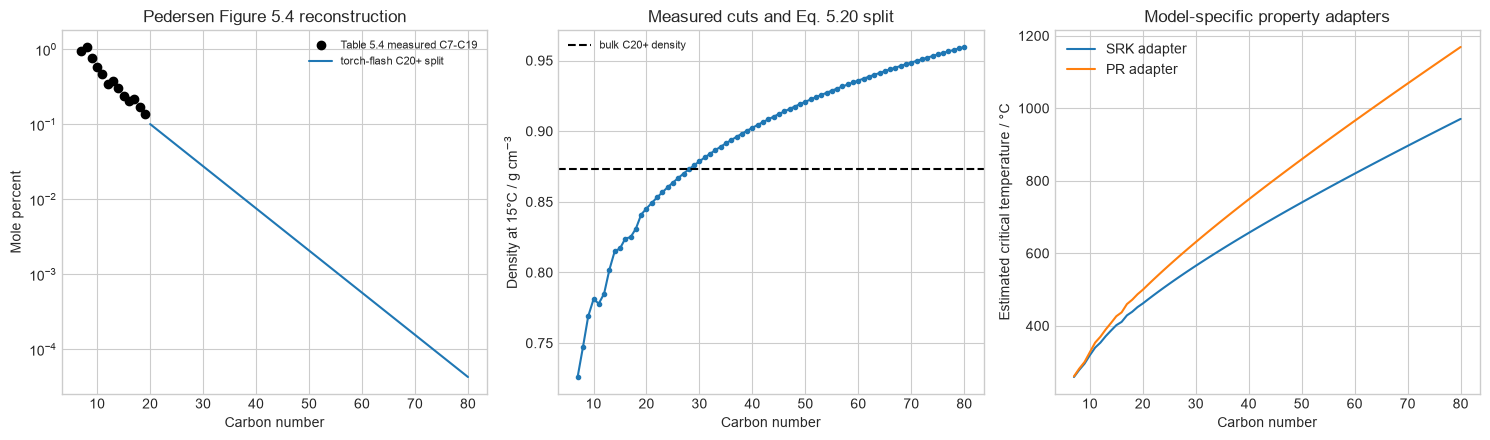

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].semilogy(
    measured.carbon_numbers,
    measured.mole_fractions * 100.0,
    "ko",
    label="Table 5.4 measured C7-C19",
)
axes[0].semilogy(
    pedersen_plus.carbon_numbers,
    pedersen_plus.mole_fractions * 100.0,
    "-",
    label="torch-flash C20+ split",
)
axes[0].set(
    xlabel="Carbon number",
    ylabel="Mole percent",
    title="Pedersen Figure 5.4 reconstruction",
)
axes[0].legend(fontsize=8)

axes[1].plot(
    characterized.carbon_numbers,
    characterized.densities / 1.0e3,
    "o-",
    markersize=3,
)
axes[1].axhline(0.873, color="black", linestyle="--", label="bulk C20+ density")
axes[1].set(
    xlabel="Carbon number",
    ylabel="Density at 15°C / g cm$^{-3}$",
    title="Measured cuts and Eq. 5.20 split",
)
axes[1].legend(fontsize=8)

axes[2].plot(
    characterized.carbon_numbers,
    srk_properties.critical_temperature - 273.15,
    label="SRK adapter",
)
axes[2].plot(
    characterized.carbon_numbers,
    pr_properties.critical_temperature - 273.15,
    label="PR adapter",
)
axes[2].set(
    xlabel="Carbon number",
    ylabel="Estimated critical temperature / °C",
    title="Model-specific property adapters",
)
axes[2].legend()
fig.tight_layout()
plt.show()

Table 5.8 contains 61 generated C20–C80 rows. The five published checkpoints
below span the first cut, the distribution body, the property maxima, and the
final tail. This is a direct numerical comparison against printed values, not
merely a balance check. Small differences are expected from the book's
rounded inputs and output columns.

In [7]:
pedersen_checkpoints = pd.DataFrame(
    [
        (20, 0.1010, 0.845, 460.8, 14.87, 0.932),
        (28, 0.0359, 0.873, 546.0, 13.12, 1.151),
        (40, 0.00761, 0.902, 656.3, 12.17, 1.344),
        (60, 0.000574, 0.936, 819.7, 11.75, 1.253),
        (80, 0.0000432, 0.960, 970.7, 11.74, 0.697),
    ],
    columns=[
        "carbon_number",
        "table_mole_percent",
        "table_density_g_cm3",
        "table_Tc_C",
        "table_Pc_bar",
        "table_omega",
    ],
)
for row_index, row in pedersen_checkpoints.iterrows():
    index = int(row["carbon_number"]) - 7
    pedersen_checkpoints.loc[row_index, "calculated_mole_percent"] = float(
        characterized.mole_fractions[index] * 100.0
    )
    pedersen_checkpoints.loc[row_index, "calculated_density_g_cm3"] = float(
        characterized.densities[index] / 1.0e3
    )
    pedersen_checkpoints.loc[row_index, "calculated_Tc_C"] = float(
        srk_properties.critical_temperature[index] - 273.15
    )
    pedersen_checkpoints.loc[row_index, "calculated_Pc_bar"] = float(
        srk_properties.critical_pressure[index] / 1.0e5
    )
    pedersen_checkpoints.loc[row_index, "calculated_omega"] = float(
        srk_properties.acentric_factor[index]
    )
display(pedersen_checkpoints.round(6))

for quantity, tolerance in {
    "mole_percent": 0.012,
    "density_g_cm3": 0.002,
    "Tc_C": 1.2,
    "Pc_bar": 0.08,
    "omega": 0.006,
}.items():
    error = (
        pedersen_checkpoints[f"calculated_{quantity}"]
        - pedersen_checkpoints[f"table_{quantity}"]
    ).abs()
    assert error.max() < tolerance

,carbon_number,table_mole_percent,table_density_g_cm3,table_Tc_C,table_Pc_bar,table_omega,calculated_mole_percent,calculated_density_g_cm3,calculated_Tc_C,calculated_Pc_bar,calculated_omega
0,20,0.101000,0.845,460.8,14.87,0.932,0.101167,0.845232,461.559754,14.830948,0.933684
1,28,0.035900,0.873,546.0,13.12,1.151,0.035921,0.872991,546.052994,13.118204,1.151329
2,40,0.007610,0.902,656.3,12.17,1.344,0.007600,0.902416,656.311263,12.168714,1.344343
3,60,0.000574,0.936,819.7,11.75,1.253,0.000571,0.935867,819.725876,11.753812,1.253419
4,80,0.000043,0.960,970.7,11.74,0.697,0.000043,0.959601,970.749244,11.745834,0.697087


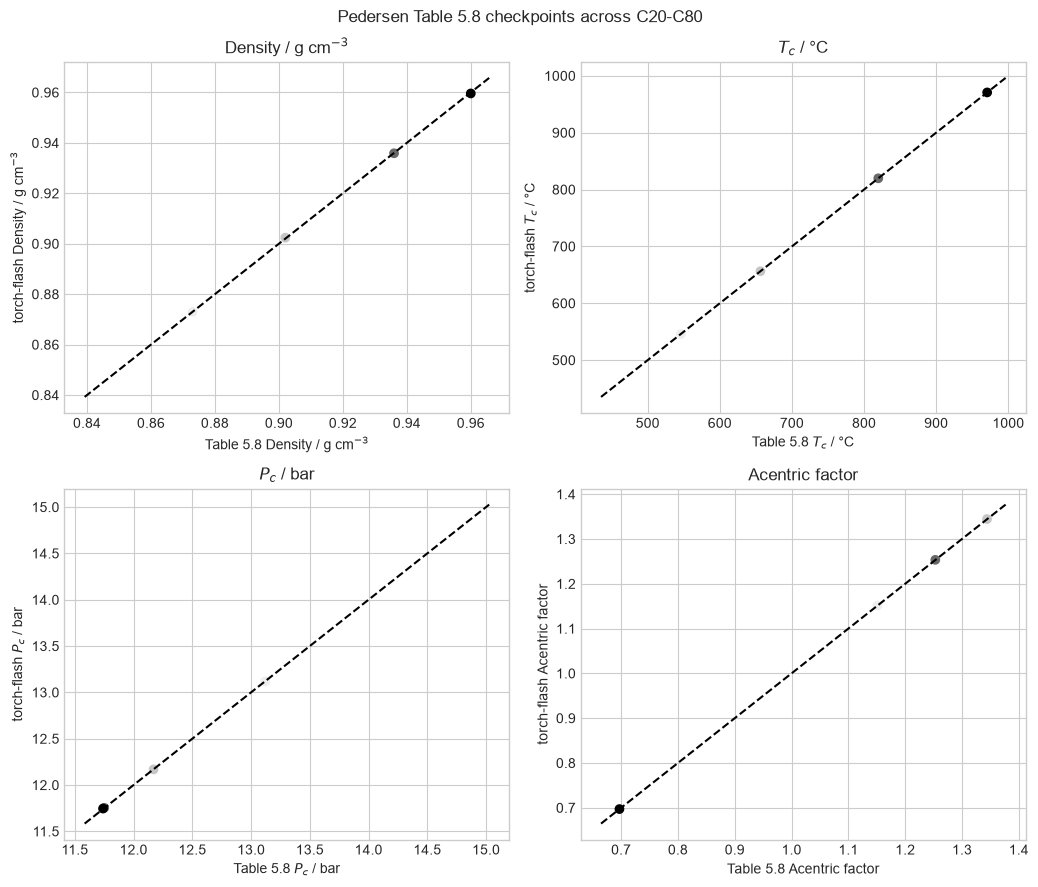

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9))
for ax, quantity, label in (
    (axes[0, 0], "density_g_cm3", "Density / g cm$^{-3}$"),
    (axes[0, 1], "Tc_C", r"$T_c$ / °C"),
    (axes[1, 0], "Pc_bar", r"$P_c$ / bar"),
    (axes[1, 1], "omega", "Acentric factor"),
):
    reference = pedersen_checkpoints[f"table_{quantity}"]
    calculated_values = pedersen_checkpoints[f"calculated_{quantity}"]
    lower = min(reference.min(), calculated_values.min())
    upper = max(reference.max(), calculated_values.max())
    margin = 0.05 * (upper - lower if upper > lower else 1.0)
    ax.scatter(reference, calculated_values, c=pedersen_checkpoints["carbon_number"])
    ax.plot([lower - margin, upper + margin], [lower - margin, upper + margin], "k--")
    ax.set(
        xlabel=f"Table 5.8 {label}",
        ylabel=f"torch-flash {label}",
        title=label,
    )
fig.suptitle("Pedersen Table 5.8 checkpoints across C20-C80")
fig.tight_layout()
plt.show()

## Pedersen Table 5.9: equal-weight lumping

Equations 5.29–5.31 use mass-weighted averages of \(T_c\), \(P_c\), and
\(\omega\). Cut boundaries are placed between whole SCN fractions, so the
three groups are only approximately equal in mass.

In [9]:
lumped = equal_weight_lump(
    characterized,
    3,
    properties={
        "critical_temperature": srk_properties.critical_temperature,
        "critical_pressure": srk_properties.critical_pressure,
        "acentric_factor": srk_properties.acentric_factor,
    },
)
table_5_9 = pd.DataFrame(
    {
        "lump": ("C7-C11", "C12-C18", "C19-C80"),
        "table_mole_percent": (3.87, 1.86, 0.97),
        "table_Tc_K": (568.0, 668.9, 817.3),
        "table_Pc_bar": (26.8, 17.4, 13.5),
        "table_omega": (0.530, 0.762, 1.108),
        "calculated_mole_percent": lumped.mole_fractions * 100.0,
        "calculated_Tc_K": lumped.properties["critical_temperature"],
        "calculated_Pc_bar": lumped.properties["critical_pressure"] / 1.0e5,
        "calculated_omega": lumped.properties["acentric_factor"],
    }
)
display(table_5_9.round(4))
assert lumped.names == tuple(table_5_9["lump"])
assert (
    np.max(
        np.abs(table_5_9["calculated_mole_percent"] - table_5_9["table_mole_percent"])
    )
    < 0.006
)
assert np.max(np.abs(table_5_9["calculated_Tc_K"] - table_5_9["table_Tc_K"])) < 0.12
assert np.max(np.abs(table_5_9["calculated_Pc_bar"] - table_5_9["table_Pc_bar"])) < 0.04
assert np.max(np.abs(table_5_9["calculated_omega"] - table_5_9["table_omega"])) < 6.0e-4

,lump,table_mole_percent,table_Tc_K,table_Pc_bar,table_omega,calculated_mole_percent,calculated_Tc_K,calculated_Pc_bar,calculated_omega
0,C7-C11,3.87,568.0,26.8,0.530,3.869,567.9810,26.8348,0.5304
1,C12-C18,1.86,668.9,17.4,0.762,1.858,668.8556,17.3798,0.7615
2,C19-C80,0.97,817.3,13.5,1.108,0.973,817.2285,13.5198,1.1084


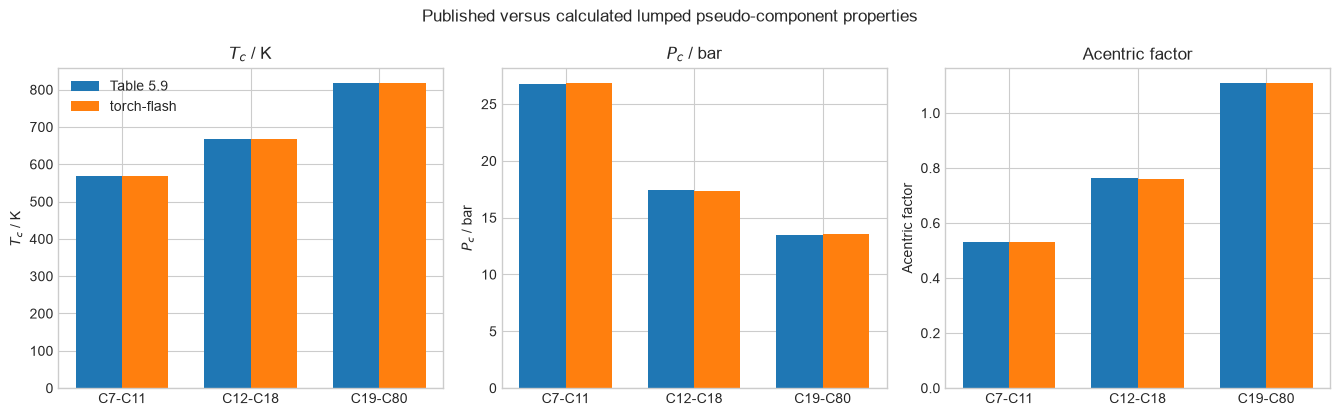

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
for ax, quantity, label in (
    (axes[0], "Tc_K", r"$T_c$ / K"),
    (axes[1], "Pc_bar", r"$P_c$ / bar"),
    (axes[2], "omega", "Acentric factor"),
):
    positions = np.arange(3)
    width = 0.36
    ax.bar(
        positions - width / 2,
        table_5_9[f"table_{quantity}"],
        width,
        label="Table 5.9",
    )
    ax.bar(
        positions + width / 2,
        table_5_9[f"calculated_{quantity}"],
        width,
        label="torch-flash",
    )
    ax.set_xticks(positions, table_5_9["lump"])
    ax.set(ylabel=label, title=label)
axes[0].legend()
fig.suptitle("Published versus calculated lumped pseudo-component properties")
fig.tight_layout()
plt.show()

## Method sensitivity: same C20+ bulk data

Whitson's gamma family introduces an explicit shape \(\alpha\); Pedersen's
logarithmic split is equivalent in spirit to the exponential
\(\alpha=1\) case but not identical because its discrete carbon-number mass
relation and endpoints differ. The comparison below is therefore a
sensitivity study, not a claim that either inferred distribution is
experimental truth. Both preserve the same C20+ mole and mass moments.

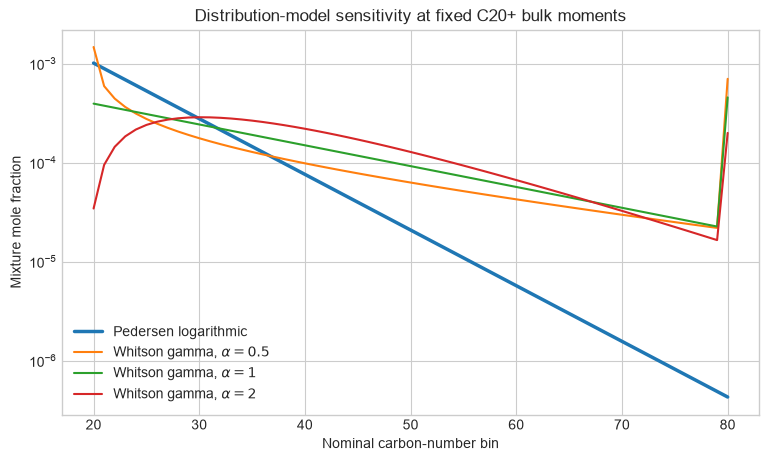

,method,sum_z,average_M_g_mol
0,Pedersen logarithmic,0.00833,377.0
1,Whitson gamma alpha=0.5,0.00833,377.0
2,Whitson gamma alpha=1,0.00833,377.0
3,Whitson gamma alpha=2,0.00833,377.0


In [11]:
whitson_same_bulk = {
    shape: whitson_gamma_split(
        0.00833,
        0.377,
        first_carbon_number=20,
        max_carbon_number=80,
        shape=shape,
    )
    for shape in (0.5, 1.0, 2.0)
}
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(
    pedersen_plus.carbon_numbers,
    pedersen_plus.mole_fractions,
    linewidth=2.5,
    label="Pedersen logarithmic",
)
for shape, distribution in whitson_same_bulk.items():
    ax.semilogy(
        distribution.carbon_numbers,
        distribution.mole_fractions,
        label=rf"Whitson gamma, $\alpha={shape:g}$",
    )
ax.set(
    xlabel="Nominal carbon-number bin",
    ylabel="Mixture mole fraction",
    title="Distribution-model sensitivity at fixed C20+ bulk moments",
)
ax.legend()
plt.show()

method_balances = pd.DataFrame(
    [
        {
            "method": "Pedersen logarithmic",
            "sum_z": float(pedersen_plus.total_mole_fraction),
            "average_M_g_mol": float(pedersen_plus.average_molar_mass * 1.0e3),
        },
        *[
            {
                "method": f"Whitson gamma alpha={shape:g}",
                "sum_z": float(distribution.total_mole_fraction),
                "average_M_g_mol": float(distribution.average_molar_mass * 1.0e3),
            }
            for shape, distribution in whitson_same_bulk.items()
        ],
    ]
)
display(method_balances)
assert np.allclose(method_balances["sum_z"], 0.00833, atol=2.0e-15)
assert np.allclose(method_balances["average_M_g_mol"], 377.0, atol=2.0e-10)

## Conclusions and applicability

- All 120 printed quantities in Whitson Table 5.4 (60 mole fractions and
  60 conditional molar masses) are reproduced within their printed rounding.
- The Pedersen North Sea condensate reproduces the C20+ mole, mass, and
  volume balances, five checkpoints spanning Table 5.8, and every lump in
  Table 5.9.
- Splitting and lumping are model-neutral. `pedersen_cubic_properties` is an
  explicitly named SRK/PR adapter; CPA has a separate heavy-cut adapter.
- A measured extended composition is preferable to any inferred tail. The
  gamma shape, maximum carbon number, anchor density, and lump count should
  remain visible calibration choices rather than hidden defaults.
- The Whitson Appendix C five-point Gaussian quadrature uses an additional
  deliberately modified heaviest-cut constraint. It is not represented by
  this SCN-bin validation and should not be confused with Table 5.4 GAMSPL.